# Exploratory Data Analysis: ZoomCharts Inventory Management

I will be using Python to first load and clean the data, performing an exploratory data analysis of the inventory data. For the actual analysis to draw insight from the data, I will be using PostgreSQL, and finally, Tableau for the visualisations.

Before I begin to optimise inventory performance and improve supply chain efficiency, I will check how the data is made up. That is:
- what variables it has,
- the viriance and distribution of the data,
- the relationship of between variables,
- presence (or lack of) null values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Before any exploaration can begin, I need to read both the data dictionary and the actual dataset. The reason I include the data dictionary is because it will serve as a reference for the accuracy of the dataset.

In [2]:
data_dictionary = pd.read_excel('Documents/ZoomChart Inventory Management/Inventory Management_C25_English.xlsx', sheet_name='Data Dictionary')

In [3]:
data_dictionary

,Column Name,Description
0,Product_ID,Unique identifier for the product
1,Product_Name,Name of the product
2,Category,Category to which the product belongs
3,Unit_Price,Price per unit of the product
4,Stock_Quantity,Quantity of the product available in stock
5,Stock_Level,"Stock level category (e.g., Low, Medium, High)"
6,Reorder_Point,Minimum quantity at which reordering is triggered
7,Lead_Time_Days,Number of days it takes to receive the product...
8,Last_Restock_Date,Date when the product was last restocked
9,Supplier_ID,Unique identifier for the product supplier


In [4]:
inventory = pd.read_csv('Documents/ZoomChart Inventory Management/Inventory.csv')

In [5]:
inventory.head()

,Product_ID,Product_Name,Category,Unit_Price,Stock_Quantity,Stock_Level,Reorder_Point,Lead_Time_Days,Last_Restock_Date,Supplier_ID,Warehouse_Location,Min_Order_Quantity,Status,Entry_Date,Country,Latitude,Longitude
0,SKU002022,Product_2022,Clothing,472.56,591,Mid,62,27,2024/05/19,SUP012,AISLE-01-SHELF-01,14,In Stock,2023/10/25,Germany,47.7010,10.0581
1,SKU002075,Product_2075,Clothing,374.26,136,Low,74,20,2024/08/09,SUP027,AISLE-01-SHELF-01,29,In Stock,2024/02/18,Spain,36.8926,-5.4515
2,SKU002523,Product_2523,Toys,29.11,176,Low,38,14,2023/09/12,SUP040,AISLE-01-SHELF-01,5,In Stock,2023/06/20,Spain,39.3519,-3.9471
3,SKU003188,Product_3188,Home & Garden,56.32,682,Mid,52,14,2024/05/28,SUP001,AISLE-01-SHELF-01,18,Out of Stock,2024/04/06,Sweden,62.9581,13.4963
4,SKU003768,Product_3768,Sports,512.09,522,Mid,72,5,2025/05/26,SUP008,AISLE-01-SHELF-01,24,In Stock,2024/06/30,Italy,37.8537,15.9189


### Exploration

In [6]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_ID          5000 non-null   object 
 1   Product_Name        5000 non-null   object 
 2   Category            5000 non-null   object 
 3   Unit_Price          5000 non-null   float64
 4   Stock_Quantity      5000 non-null   int64  
 5   Stock_Level         5000 non-null   object 
 6   Reorder_Point       5000 non-null   int64  
 7   Lead_Time_Days      5000 non-null   int64  
 8   Last_Restock_Date   5000 non-null   object 
 9   Supplier_ID         5000 non-null   object 
 10  Warehouse_Location  5000 non-null   object 
 11  Min_Order_Quantity  5000 non-null   int64  
 12  Status              5000 non-null   object 
 13  Entry_Date          5000 non-null   object 
 14  Country             5000 non-null   object 
 15  Latitude            5000 non-null   float64
 16  Longit

The data is made up of 17 columns and 5000 rows. 

In [7]:
inventory.describe()

,Unit_Price,Stock_Quantity,Reorder_Point,Lead_Time_Days,Min_Order_Quantity,Latitude,Longitude
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,498.759508,500.653200,53.387600,14.962800,27.151400,49.750184,7.951881
std,284.787265,287.651942,26.035056,8.425296,12.906022,6.479998,8.097179
min,10.070000,0.000000,10.000000,1.000000,5.000000,36.010500,-9.291900
25%,248.910000,254.000000,31.000000,8.000000,16.000000,46.530525,2.710850
50%,501.045000,500.000000,53.000000,15.000000,27.000000,50.338000,7.335600
75%,743.855000,749.000000,76.000000,22.000000,38.000000,52.909575,14.414175
max,999.730000,999.000000,99.000000,29.000000,49.000000,69.093000,24.156400


The statistical summary of the numerical columns shows that there are products with stock quantity at 0. Moreover, I can see that the minimum order quantity required is 5 and the minimum unit price is 10.07.

In [8]:
inventory.nunique().to_frame("unique_count")

,unique_count
Product_ID,5000
Product_Name,5000
Category,7
Unit_Price,4862
Stock_Quantity,998
Stock_Level,3
Reorder_Point,90
Lead_Time_Days,29
Last_Restock_Date,986
Supplier_ID,50


Looking at theese unique count results, I notice a few things, namely:
- besides the unique product id, all product names are also unique,
- there are 989 warehouse locations spread between 10 countries, and the cities/provinces implied by the raw coordinates.
- how spread out are the 45 unique MOQ values across the 5000 products?

In [9]:
inventory.isna().sum().to_frame('null_count')

,null_count
Product_ID,0
Product_Name,0
Category,0
Unit_Price,0
Stock_Quantity,0
Stock_Level,0
Reorder_Point,0
Lead_Time_Days,0
Last_Restock_Date,0
Supplier_ID,0


The dataset is well populated with all variables having data.

In [10]:
inventory['Last_Restock_Date'].agg(['min', 'max'])

min    2023/04/03
max    2026/03/05
Name: Last_Restock_Date, dtype: object

### Exploratory Charts

Moving on from missing data, I count the number of products per category. The bar graph below visualises the results.

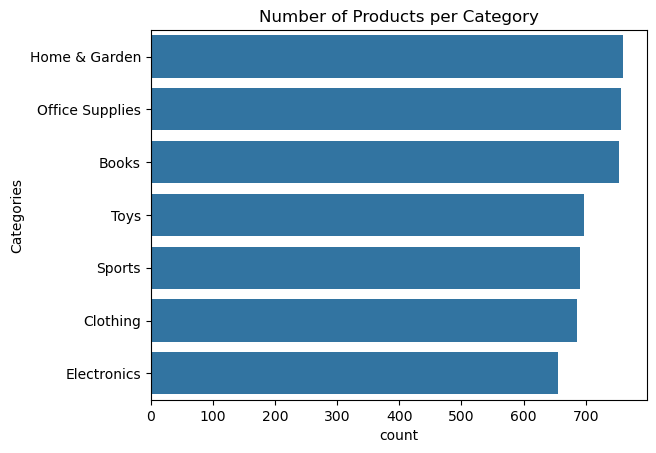

In [11]:
plt.figure()
sns.countplot(data=inventory,y='Category',order=inventory['Category'].value_counts().index)
plt.title('Number of Products per Category')
plt.ylabel('Categories')
plt.show()

Next, count of products by country.

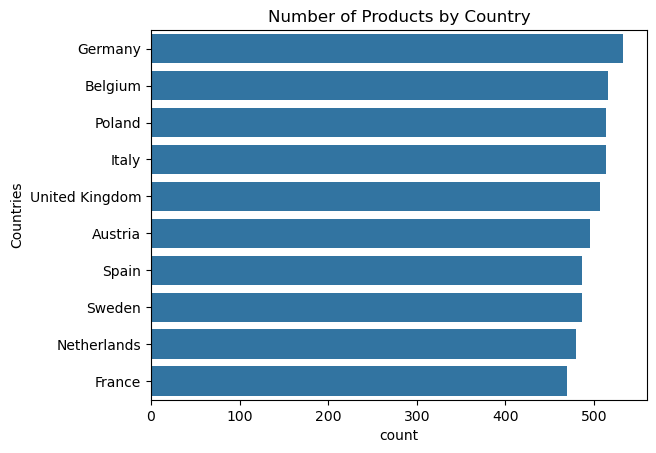

In [12]:
plt.figure()
sns.countplot(data=inventory,y='Country', order=inventory['Country'].value_counts().index)
plt.title('Number of Products by Country')
plt.ylabel('Countries')
plt.show()

The histogram below shows the distribution of supplier enforced minimum order quantinty.

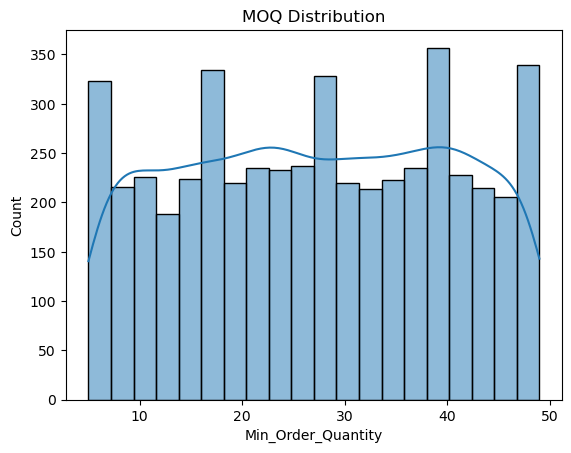

In [13]:
plt.figure()
sns.histplot(data=inventory,x='Min_Order_Quantity',bins=20, kde=True)
plt.title('MOQ Distribution')
plt.show()

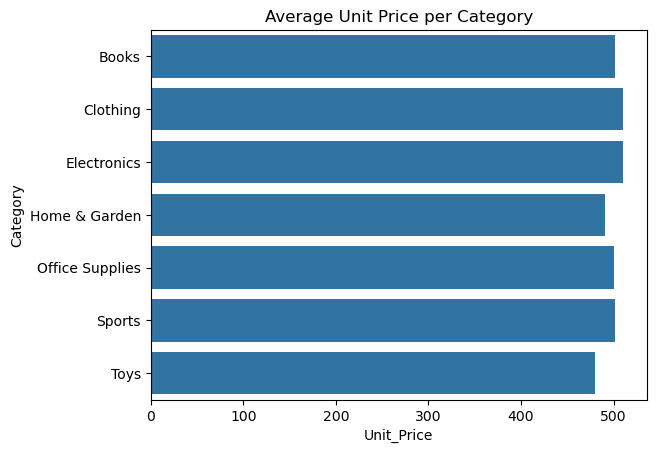

In [14]:
category_stats = inventory.groupby('Category')['Unit_Price'].mean()

plt.figure()
sns.barplot(data=category_stats, orient='h')
plt.title('Average Unit Price per Category')
plt.show()

The average unit prices per category all fall over 400 Euros. 

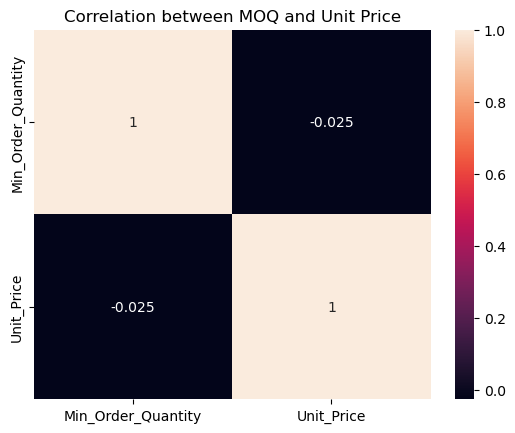

In [15]:
correlation = inventory[['Min_Order_Quantity', 'Unit_Price']].corr()

plt.figure()
sns.heatmap(correlation,annot=True)
plt.title('Correlation between MOQ and Unit Price')
plt.show()

There is no correlation between the MOQ and the unit price

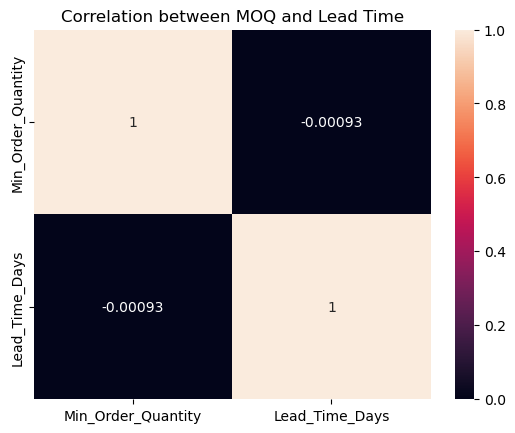

In [16]:
correlation = inventory[['Min_Order_Quantity', 'Lead_Time_Days']].corr()

plt.figure()
sns.heatmap(correlation,annot=True)
plt.title('Correlation between MOQ and Lead Time')
plt.show()

The correlation between required minimum order quantity and lead time is zero, indicating no linear relationship between the two variables.This suggests that suppliers requiring larger minimum orders do not necessarily have longer or short delivery times.